# 03 - arquitectura de linea de base

## Proyecto
**Clasificación de razas de perros y gatos con CNN y Transfer Learning**  
Dataset: **Oxford-IIIT Pet Dataset**

## Objetivo de este notebook
En este notebook construiremos y entrenaremos una **línea base** para el proyecto.

### ¿Qué significa línea base?
Una línea base es un modelo inicial, relativamente simple, que sirve como punto de comparación.  
No busca necesariamente el mejor rendimiento posible, sino darnos una referencia clara antes de pasar a modelos más potentes como los de **transfer learning**.

### Lo que haremos
1. cargar el dataset,
2. preparar el pipeline de entrada,
3. definir una CNN sencilla,
4. entrenar el modelo,
5. visualizar curvas de entrenamiento,
6. evaluar en el conjunto de prueba,
7. analizar resultados con matriz de confusión y ejemplos de predicción.

> Este notebook sí entrena un modelo. La idea es obtener un primer resultado reproducible y comparable.

## 1. Importación de librerías

En esta sección importamos las librerías principales:

- **tensorflow**: framework para construir y entrenar la red convolucional.
- **tensorflow_datasets**: para cargar el Oxford-IIIT Pet Dataset.
- **matplotlib** y **seaborn**: para visualización de curvas y matriz de confusión.
- **numpy**: apoyo numérico.
- **scikit-learn**: para métricas adicionales como matriz de confusión y reporte de clasificación.

También fijamos una semilla para hacer el entrenamiento más reproducible.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE
sns.set_context("notebook")

print("TensorFlow version:", tf.__version__)
print("TensorFlow Datasets version:", tfds.__version__)

TensorFlow version: 2.20.0
TensorFlow Datasets version: 4.9.10


## 2. Carga del dataset

Usaremos la misma estrategia de partición que en el notebook de preprocesado:

- `train[:80%]` → entrenamiento
- `train[80%:]` → validación
- `test` → prueba

Esto nos permite monitorear el modelo durante entrenamiento y reservar un conjunto final para evaluación objetiva.

In [2]:
dataset_name = "oxford_iiit_pet"

(train_raw, val_raw, test_raw), info = tfds.load(
    dataset_name,
    split=["train[:80%]", "train[80%:]", "test"],
    with_info=True,
    as_supervised=False
)

class_names = info.features["label"].names
num_classes = info.features["label"].num_classes

print("Número de clases:", num_classes)
print("Train:", tf.data.experimental.cardinality(train_raw).numpy())
print("Validation:", tf.data.experimental.cardinality(val_raw).numpy())
print("Test:", tf.data.experimental.cardinality(test_raw).numpy())

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Número de clases: 37
Train: 2944
Validation: 736
Test: 3669


## 3. Hiperparámetros del baseline

Aquí definimos algunos valores que controlan el entrenamiento.

### Variables
- **IMG_SIZE**: tamaño de entrada de las imágenes.
- **BATCH_SIZE**: tamaño del lote.
- **EPOCHS**: máximo número de épocas.
- **LEARNING_RATE**: tasa de aprendizaje del optimizador Adam.

### Comentario
Aunque podrían usarse valores más agresivos, elegimos una configuración razonable para que el notebook sea estable y reproducible en Google Colab.

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000
EPOCHS = 12
LEARNING_RATE = 1e-3

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)
print("LEARNING_RATE:", LEARNING_RATE)

IMG_SIZE: (224, 224)
BATCH_SIZE: 32
EPOCHS: 12
LEARNING_RATE: 0.001


## 4. Preprocesado para la línea base

Como este modelo será una CNN simple entrenada desde cero, aplicaremos un preprocesado básico:

1. convertir la imagen a `float32`,
2. redimensionarla a `224x224`,
3. normalizar sus valores al rango `[0, 1]`,
4. devolver la tupla `(imagen, etiqueta)`.

Esto es suficiente para una arquitectura base y nos deja una referencia clara antes de usar arquitecturas preentrenadas.

In [4]:
def preprocess_example(example, img_size=IMG_SIZE):
    image = example["image"]
    label = example["label"]

    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, img_size)
    image = image / 255.0

    return image, label

## 5. Definición de data augmentation

Incluimos una pequeña etapa de aumento de datos para ayudar a la generalización del modelo.

### Transformaciones elegidas
- **volteo horizontal**
- **pequeña rotación**
- **pequeño zoom**

Estas transformaciones son moderadas para no distorsionar excesivamente las razas.

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

data_augmentation

<Sequential name=data_augmentation, built=False>

## 6. Construcción de los datasets

Aquí armamos el pipeline con `tf.data`.

### Operaciones clave
- `map`: aplica el preprocesado.
- `cache`: evita recalcular transformaciones básicas.
- `shuffle`: mezcla el conjunto de entrenamiento.
- `batch`: agrupa ejemplos.
- `prefetch`: mejora el rendimiento del pipeline.

Solo entrenamiento se mezcla, porque validación y prueba deben conservar un flujo estable.

In [6]:
def build_dataset(ds, training=False):
    ds = ds.map(preprocess_example, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()

    if training:
        ds = ds.shuffle(SHUFFLE_BUFFER, seed=SEED)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = build_dataset(train_raw, training=True)
val_ds = build_dataset(val_raw, training=False)
test_ds = build_dataset(test_raw, training=False)

print("Datasets listos.")

Datasets listos.


## 7. Inspección rápida del pipeline

Antes de entrenar, verificamos que el pipeline entrega tensores con la forma correcta.

In [7]:
images_batch, labels_batch = next(iter(train_ds))

print("Shape imágenes:", images_batch.shape)
print("Shape etiquetas:", labels_batch.shape)
print("Tipo de dato:", images_batch.dtype)
print("Mínimo:", tf.reduce_min(images_batch).numpy())
print("Máximo:", tf.reduce_max(images_batch).numpy())

Shape imágenes: (32, 224, 224, 3)
Shape etiquetas: (32,)
Tipo de dato: <dtype: 'float32'>
Mínimo: 0.0
Máximo: 1.0


## 8. Visualización de un lote preprocesado

Esto nos permite confirmar visualmente que las imágenes:
- se redimensionaron bien,
- conservan información útil,
- y siguen alineadas con sus etiquetas.

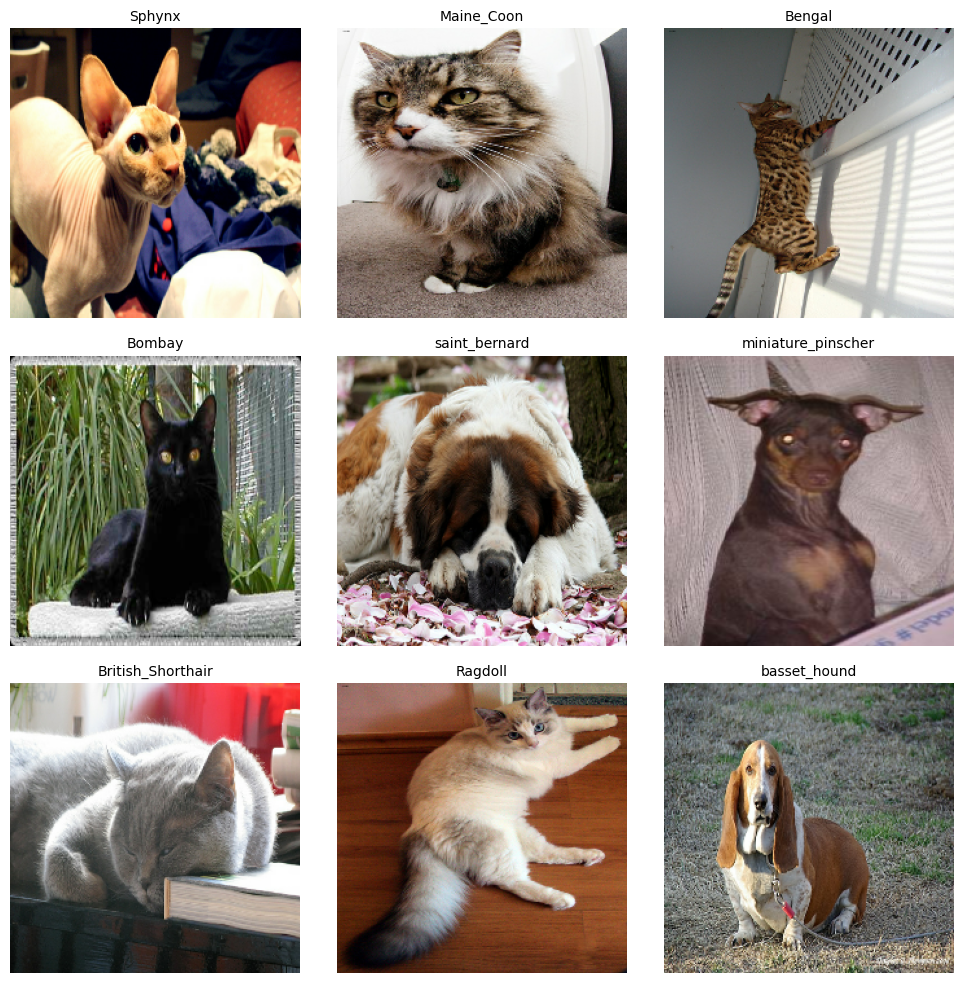

In [8]:
def show_batch(images, labels, class_names, n=9, figsize=(10, 10)):
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])], fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(images_batch.numpy(), labels_batch.numpy(), class_names, n=9)

## 9. Definición de la arquitectura de línea base

Construiremos una CNN relativamente simple con la siguiente lógica:

1. **entrada** de tamaño `224x224x3`,
2. **data augmentation**,
3. varios bloques `Conv2D + MaxPooling`,
4. **GlobalAveragePooling2D** para resumir mapas de activación,
5. una capa densa intermedia con dropout,
6. una capa final `Dense(num_classes, softmax)`.

### ¿Por qué esta arquitectura?
- es lo suficientemente simple para servir como baseline,
- pero lo bastante expresiva como para aprender patrones básicos del dataset,
- y permite comparar después contra modelos preentrenados.

In [9]:
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=37):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        data_augmentation,

        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ], name="baseline_cnn")

    return model

model = build_baseline_cnn(input_shape=IMG_SIZE + (3,), num_classes=num_classes)
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 463,717 (1.77 MB)

 Trainable params: 463,717 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Compilación del modelo

Para entrenar el modelo configuramos:

- **Optimizador**: `Adam`
- **Función de pérdida**: `SparseCategoricalCrossentropy`
- **Métrica principal**: `accuracy`

### ¿Por qué `SparseCategoricalCrossentropy`?
Porque nuestras etiquetas son enteros (`0, 1, 2, ...`) y no vectores one-hot.

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Modelo compilado correctamente.")

Modelo compilado correctamente.


## 11. Callbacks

Usaremos dos callbacks principales:

- **EarlyStopping**: detiene el entrenamiento si la métrica de validación deja de mejorar.
- **ReduceLROnPlateau**: reduce la tasa de aprendizaje cuando el modelo se estanca.

### Beneficio
Esto suele mejorar estabilidad y evita entrenar muchas épocas innecesarias.

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

callbacks

## 12. Entrenamiento del baseline

Ahora entrenamos la CNN base sobre el conjunto de entrenamiento y monitoreamos su desempeño en validación.

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 483s 5s/step - accuracy: 0.0292 - loss: 3.6126 - val_accuracy: 0.0190 - val_loss: 3.6104 - learning_rate: 0.0010
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 456s 5s/step - accuracy: 0.0309 - loss: 3.6079 - val_accuracy: 0.0272 - val_loss: 3.5985 - learning_rate: 0.0010
Epoch 3/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 464s 5s/step - accuracy: 0.0316 - loss: 3.6031 - val_accuracy: 0.0245 - val_loss: 3.5991 - learning_rate: 0.0010
Epoch 4/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 506s 5s/step - accuracy: 0.0367 - loss: 3.5850 - val_accuracy: 0.0421 - val_loss: 3.5772 - learning_rate: 0.0010
Epoch 5/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 500s 5s/step - accuracy: 0.0394 - loss: 3.5684 - val_accuracy: 0.0421 - val_loss: 3.5670 - learning_rate: 0.0010
Epoch 6/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 468s 5s/step - accuracy: 0.0411 - loss: 3.5522 - val_accuracy: 0.0421 - val_loss: 3.5852 - learning_rate: 0.0010
Epoch 7/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 500s 5s/step - accuracy: 0.0469 - loss: 3.5388 - val_acc

## 13. Curvas de entrenamiento

Visualizaremos:

- pérdida de entrenamiento y validación,
- accuracy de entrenamiento y validación.

Estas curvas ayudan a detectar:
- subajuste,
- sobreajuste,
- convergencia razonable.

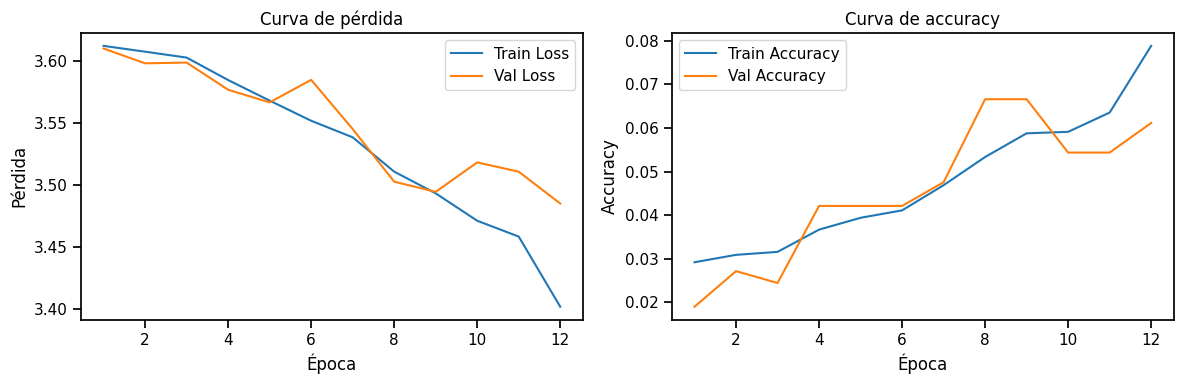

In [13]:
def plot_training_history(history):
    history_dict = history.history
    epochs_range = range(1, len(history_dict["loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history_dict["loss"], label="Train Loss")
    plt.plot(epochs_range, history_dict["val_loss"], label="Val Loss")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title("Curva de pérdida")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history_dict["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, history_dict["val_accuracy"], label="Val Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title("Curva de accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

## 14. Evaluación sobre el conjunto de prueba

Una vez terminado el entrenamiento, evaluamos el modelo sobre el conjunto de prueba.  
Este resultado es importante porque representa el desempeño final del baseline sobre datos no vistos durante entrenamiento.

In [14]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

115/115 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.0548 - loss: 3.5553
Test Loss: 3.5553
Test Accuracy: 0.0548


## 15. Predicciones sobre test

Para análisis más detallado, generaremos predicciones sobre el conjunto de prueba.

### Qué obtendremos
- probabilidades por clase,
- clase predicha (`argmax`),
- clase real.

In [15]:
y_true = []
y_pred = []
test_images_for_display = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)
    test_images_for_display.extend(images.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Número de ejemplos evaluados:", len(y_true))

Número de ejemplos evaluados: 3669


## 16. Reporte de clasificación

El reporte de clasificación muestra, por clase:

- **precision**,
- **recall**,
- **f1-score**,
- **support**.

Como son 37 clases, el reporte puede ser largo.  
Aun así, es una herramienta útil para entender dónde el baseline funciona mejor y dónde falla más.

In [16]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=3
)

print(report)

                            precision    recall  f1-score   support

                Abyssinian      0.176     0.031     0.052        98
          american_bulldog      0.019     0.020     0.019       100
 american_pit_bull_terrier      0.000     0.000     0.000       100
              basset_hound      0.052     0.500     0.095       100
                    beagle      0.038     0.050     0.043       100
                    Bengal      0.000     0.000     0.000       100
                    Birman      0.000     0.000     0.000       100
                    Bombay      0.000     0.000     0.000        88
                     boxer      0.000     0.000     0.000        99
         British_Shorthair      0.125     0.010     0.019       100
                 chihuahua      0.000     0.000     0.000       100
              Egyptian_Mau      0.029     0.010     0.015        97
    english_cocker_spaniel      0.000     0.000     0.000       100
            english_setter      0.000     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 17. Matriz de confusión

La matriz de confusión permite visualizar cómo se distribuyen los errores entre clases.  
En tareas de clasificación fina, esta visualización ayuda mucho a identificar razas que se confunden con frecuencia.

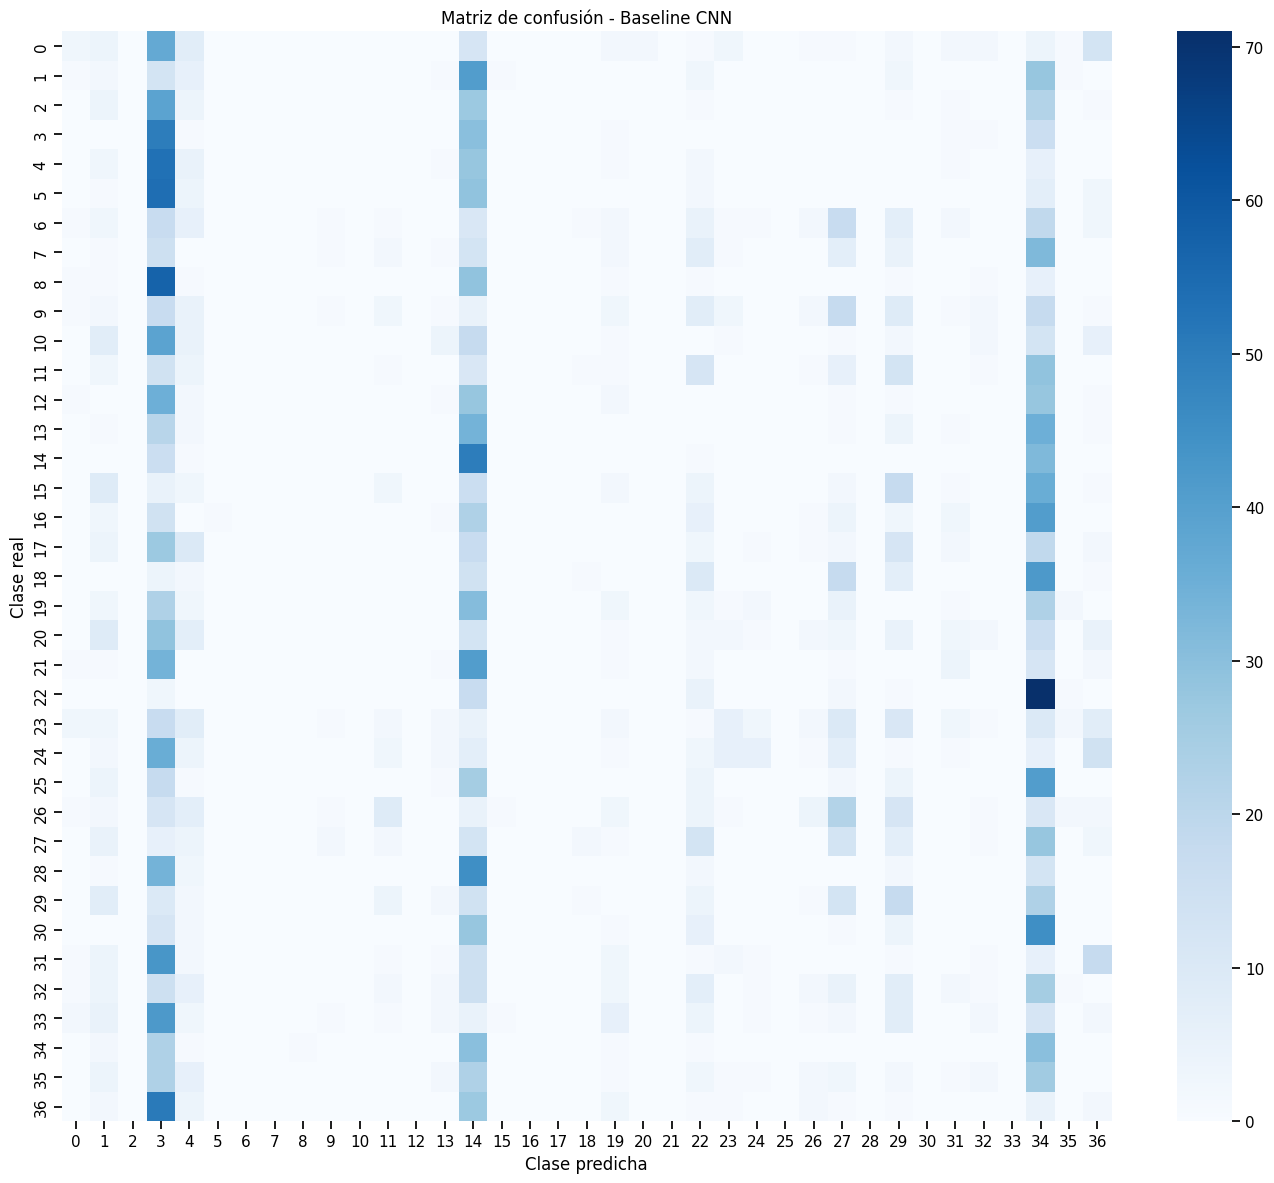

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.title("Matriz de confusión - Baseline CNN")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

## 18. Visualización de predicciones correctas e incorrectas

A continuación mostraremos algunos ejemplos del conjunto de prueba con:

- clase real,
- clase predicha,
- color del título para indicar si fue correcto o incorrecto.

Esto ayuda a interpretar el comportamiento del modelo más allá de una sola métrica global.

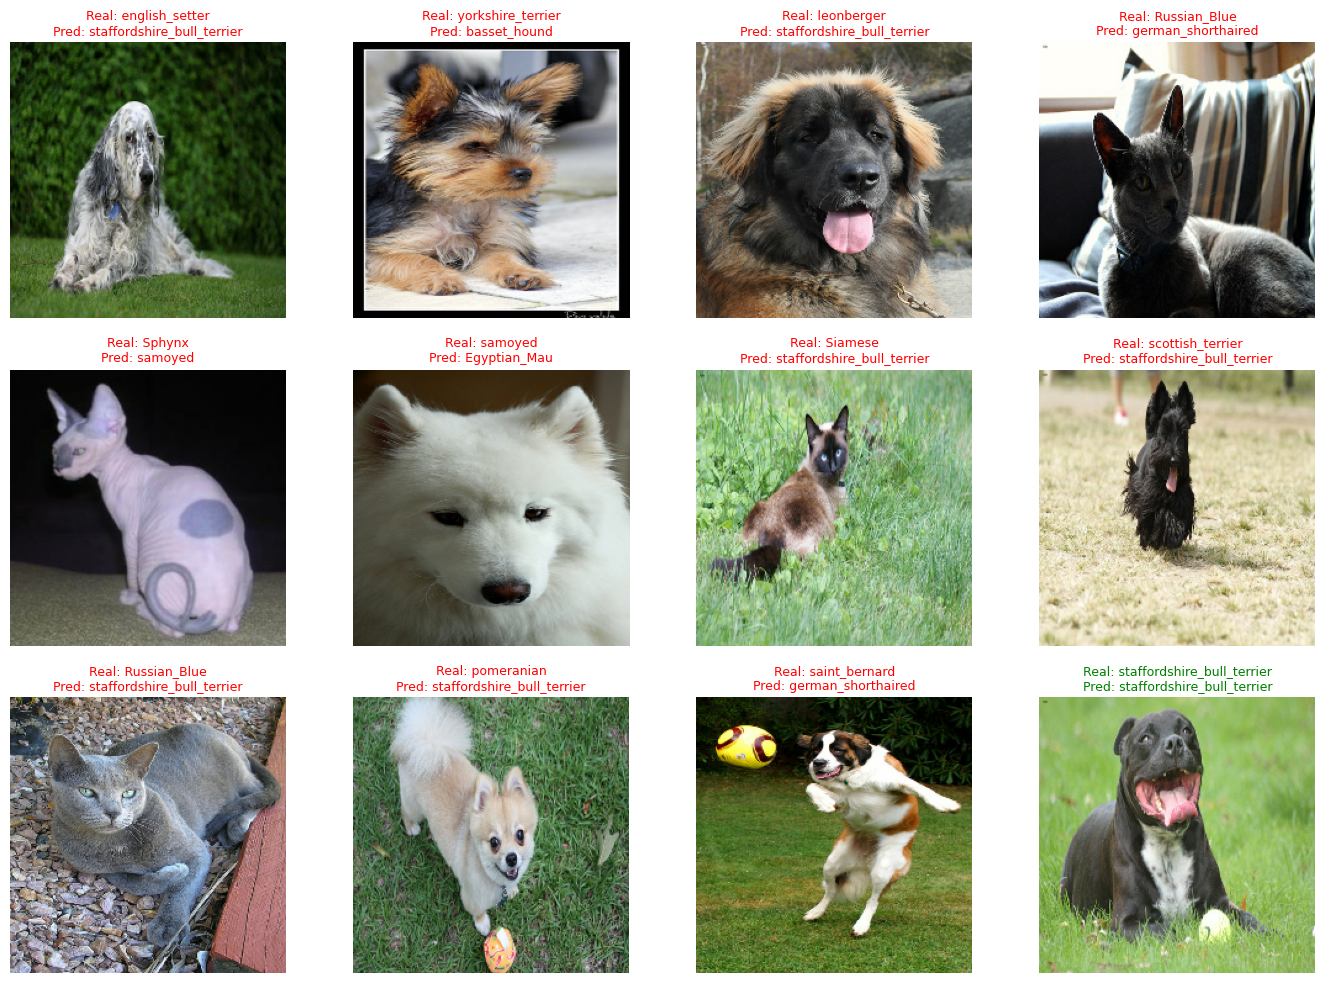

In [18]:
def show_predictions(images, y_true, y_pred, class_names, num_examples=12, seed=SEED):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(images), size=num_examples, replace=False)

    plt.figure(figsize=(14, 10))
    for i, idx in enumerate(indices, 1):
        plt.subplot(3, 4, i)
        plt.imshow(images[idx])
        true_label = class_names[int(y_true[idx])]
        pred_label = class_names[int(y_pred[idx])]
        correct = y_true[idx] == y_pred[idx]
        title_color = "green" if correct else "red"
        plt.title(f"Real: {true_label}\nPred: {pred_label}", color=title_color, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(test_images_for_display, y_true, y_pred, class_names, num_examples=12)

## 19. Análisis breve del baseline

En este punto ya tenemos un modelo base completamente funcional.  
El análisis que conviene hacer aquí es:

1. observar la **accuracy** obtenida,
2. verificar si hay señales de **sobreajuste** en las curvas,
3. identificar clases con más confusión,
4. usar este resultado como referencia para el notebook de transfer learning.

### Qué esperamos conceptualmente
Es normal que un baseline entrenado desde cero quede por debajo de un modelo preentrenado.  
Precisamente por eso este notebook es importante: nos da una referencia clara para medir la mejora posterior.

## 20. Conclusiones

Con este notebook se construyó y evaluó una primera solución al problema de clasificación de razas:

- se diseñó una CNN simple,
- se entrenó sobre el Oxford-IIIT Pet Dataset,
- se evaluó en validación y prueba,
- y se analizaron sus resultados con varias herramientas.

Este baseline servirá como punto de comparación frente a la siguiente iteración del proyecto, basada en **transfer learning**.